# EDA та очищення даних для Telecom Churn

Цей ноутбук виконує аналіз датасету, обробляє пропущені значення, видаляє зайві колонки та формує очищений файл `data/processed/cleaned_churn_data.csv`. Саме цей файл потім використовується у `src/train_model.py` для навчання моделі.

In [14]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_PATH = ROOT / "data" / "raw" / "internet_service_churn.csv"
PROCESSED_DATA_PATH = ROOT / "data" / "processed" / "cleaned_churn_data.csv"
ASSETS_DIR = ROOT / "assets"

ASSETS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)

## 1. Завантаження датасету

In [15]:
df = pd.read_csv(RAW_DATA_PATH)
df.head()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1


## 2. Загальна інформація

In [16]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.info()

Rows: 72274
Columns: 11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72274 entries, 0 to 72273
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           72274 non-null  int64  
 1   is_tv_subscriber             72274 non-null  int64  
 2   is_movie_package_subscriber  72274 non-null  int64  
 3   subscription_age             72274 non-null  float64
 4   bill_avg                     72274 non-null  int64  
 5   reamining_contract           50702 non-null  float64
 6   service_failure_count        72274 non-null  int64  
 7   download_avg                 71893 non-null  float64
 8   upload_avg                   71893 non-null  float64
 9   download_over_limit          72274 non-null  int64  
 10  churn                        72274 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 6.1 MB


In [17]:
df.describe()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
count,7.227400e+04,72274.000000,72274.000000,72274.000000,72274.000000,50702.000000,72274.000000,71893.000000,71893.000000,72274.000000,72274.000000
mean,8.463182e+05,0.815259,0.334629,2.450051,18.942483,0.716039,0.274234,43.689911,4.192076,0.207613,0.554141
std,4.891022e+05,0.388090,0.471864,2.034990,13.215386,0.697102,0.816621,63.405963,9.818896,0.997123,0.497064
min,1.500000e+01,0.000000,0.000000,-0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.222165e+05,1.000000,0.000000,0.930000,13.000000,0.000000,0.000000,6.700000,0.500000,0.000000,0.000000
50%,8.477840e+05,1.000000,0.000000,1.980000,19.000000,0.570000,0.000000,27.800000,2.100000,0.000000,1.000000
75%,1.269562e+06,1.000000,1.000000,3.300000,22.000000,1.310000,0.000000,60.500000,4.800000,0.000000,1.000000
max,1.689744e+06,1.000000,1.000000,12.800000,406.000000,2.920000,19.000000,4415.200000,453.300000,7.000000,1.000000


## 3. Перевірка пропущених значень

In [18]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

reamining_contract             21572
download_avg                     381
upload_avg                       381
is_movie_package_subscriber        0
is_tv_subscriber                   0
id                                 0
subscription_age                   0
service_failure_count              0
bill_avg                           0
download_over_limit                0
churn                              0
dtype: int64

## 4. Аналіз цільової змінної `churn`

In [19]:
churn_counts = df["churn"].value_counts()
churn_percent = df["churn"].value_counts(normalize=True) * 100

pd.DataFrame({
    "count": churn_counts,
    "percent": churn_percent.round(2)
})

,count,percent
churn,,
1,40050,55.41
0,32224,44.59


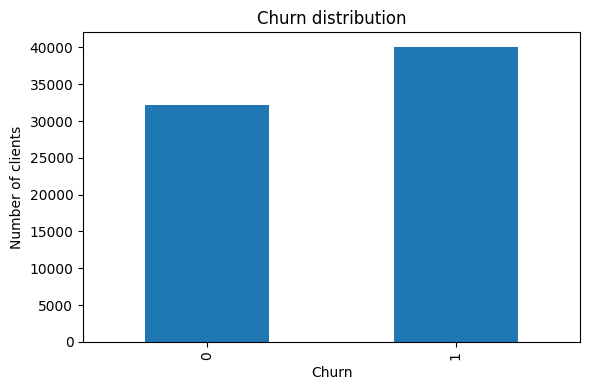

In [20]:
plt.figure(figsize=(6, 4))
df["churn"].value_counts().sort_index().plot(kind="bar")
plt.title("Churn distribution")
plt.xlabel("Churn")
plt.ylabel("Number of clients")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "churn_distribution.png")
plt.show()

## 5. Кореляції між ознаками

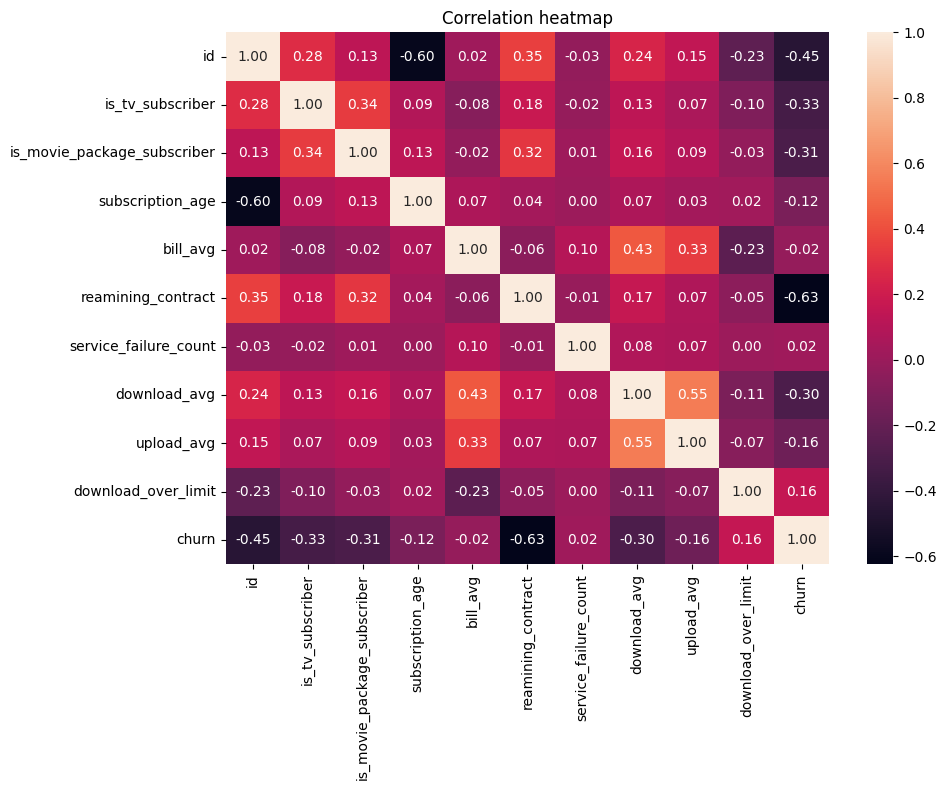

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "correlation_heatmap.png")
plt.show()

## 6. Порівняння ознак для клієнтів, які залишились і пішли

<Figure size 700x400 with 0 Axes>

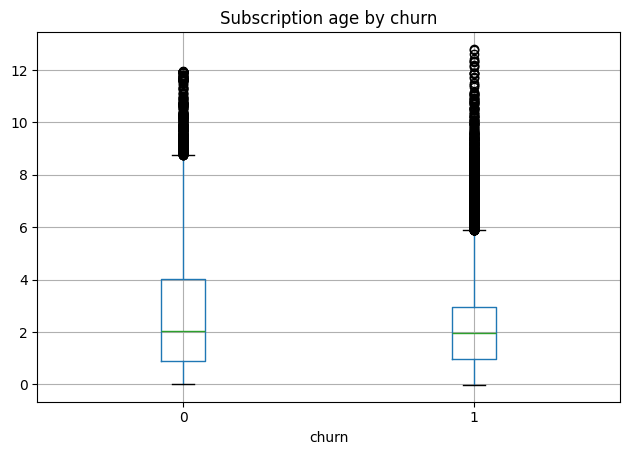

In [22]:
plt.figure(figsize=(7, 4))
df.boxplot(column="subscription_age", by="churn")
plt.title("Subscription age by churn")
plt.suptitle("")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "subscription_age_by_churn.png")
plt.show()

<Figure size 700x400 with 0 Axes>

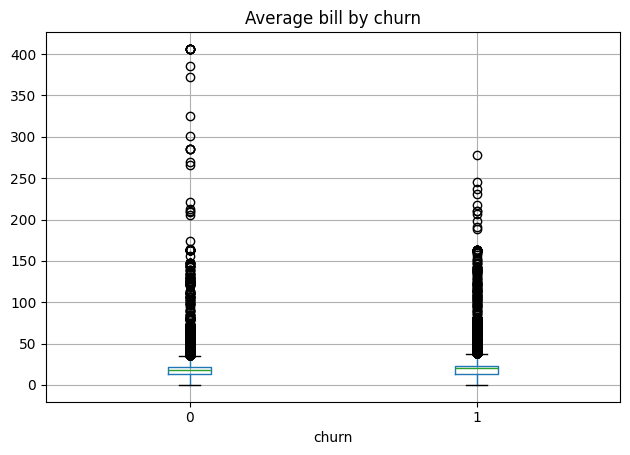

In [23]:
plt.figure(figsize=(7, 4))
df.boxplot(column="bill_avg", by="churn")
plt.title("Average bill by churn")
plt.suptitle("")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "bill_avg_by_churn.png")
plt.show()

<Figure size 700x400 with 0 Axes>

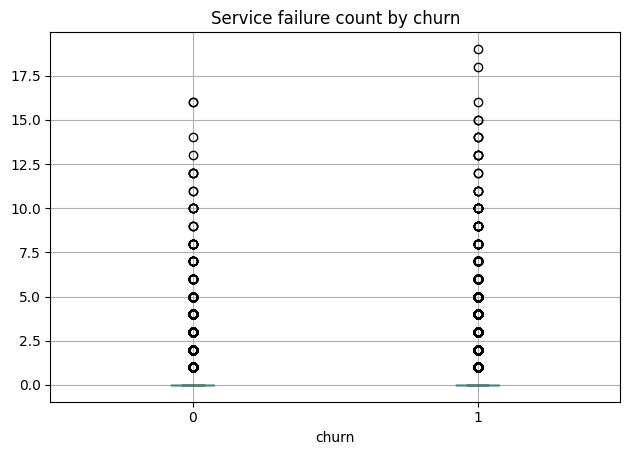

In [24]:
plt.figure(figsize=(7, 4))
df.boxplot(column="service_failure_count", by="churn")
plt.title("Service failure count by churn")
plt.suptitle("")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "service_failure_count_by_churn.png")
plt.show()

## 7. Очищення датасету

Правила очищення:

- колонка `id` видаляється, бо це технічний ідентифікатор, а не корисна ознака для моделі;
- `reamining_contract` заповнюється нулем, бо відсутнє значення можна інтерпретувати як відсутність активного залишку контракту;
- `download_avg` і `upload_avg` заповнюються медіаною, щоб не втрачати рядки;
- після очищення перевіряється, що пропусків не залишилось.

In [25]:
cleaned_df = df.copy()

if "id" in cleaned_df.columns:
    cleaned_df = cleaned_df.drop(columns=["id"])

cleaned_df["reamining_contract"] = cleaned_df["reamining_contract"].fillna(0)
cleaned_df["download_avg"] = cleaned_df["download_avg"].fillna(cleaned_df["download_avg"].median())
cleaned_df["upload_avg"] = cleaned_df["upload_avg"].fillna(cleaned_df["upload_avg"].median())

cleaned_df.isnull().sum()

is_tv_subscriber               0
is_movie_package_subscriber    0
subscription_age               0
bill_avg                       0
reamining_contract             0
service_failure_count          0
download_avg                   0
upload_avg                     0
download_over_limit            0
churn                          0
dtype: int64

## 8. Збереження очищеного датасету

In [26]:
cleaned_df.to_csv(PROCESSED_DATA_PATH, index=False)
print(f"Cleaned dataset saved to: {PROCESSED_DATA_PATH}")
print(f"Shape: {cleaned_df.shape}")

Cleaned dataset saved to: d:\GoIT_dz\DS_Final_project\data\processed\cleaned_churn_data.csv
Shape: (72274, 10)
